In [1]:
MODEL_CLS = "drnet"
DATASET = "movielens"
STRATEGY = "pointwise"
PATH_WORK_DIR = "../.."
PATH_CONFIG_FILE = f"./config/{DATASET}/{MODEL_CLS}_{STRATEGY}.yaml"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PAPER REVIEW\RECSYS\02_MLP\10_RS-DRNet


In [4]:
import sys
sys.path.append("src")

# Config

In [5]:
import pandas as pd
from recsys import config, pipeline, trainer, evaluator, utils
import drnet

In [6]:
kwargs = dict(
    path=PATH_CONFIG_FILE,
)

cfg = config.builder.config_builder(**kwargs)

In [7]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [8]:
PATH = f"./data/{cfg.dataset}.csv"
df = pd.read_csv(PATH)

In [9]:
kwargs = dict(
    df=df,
    schema=cfg.schema,
    percentaile=0.9,
)

utils.description.main(**kwargs)

number of user: 609
number of item: 8452
total interaction: 81763
interaction density: 1.5885 %
max interaction of user: 2117
max interaction of item: 315
top 10.0 % interaction of user: 344.4
top 10.0 % interaction of item: 25.0
mean interaction of user: 134
mean interaction of item: 9


In [10]:
kwargs = dict(
    df=df,
    cfg=cfg.pipeline,
)

dataloaders, interactions, histories = pipeline.builder.pipeline_builder(**kwargs)

# Modeling

In [11]:
kwargs = dict(
    num_users=cfg.model.affection.num_users,
    num_items=cfg.model.affection.num_items,
    **cfg.model.affection.params,
)

affection = drnet.affection.Module(**kwargs)

In [12]:
kwargs = dict(
    affection=affection,
    histories=histories["user"],
    num_users=cfg.model.association.num_users,
    num_items=cfg.model.association.num_items,
    **cfg.model.association.params,
)

association = drnet.association.Module(**kwargs)

In [13]:
kwargs = dict(
    affection=affection,
    association=association,
)    

model = drnet.drnet.Module(**kwargs)

# Train

In [14]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

trainer = trainer.builder.trainer_builder(**kwargs)

In [15]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = trainer.fit(**kwargs)

VALIDATION
	BEST SCORE: 0.4790
	BEST EPOCH: 11


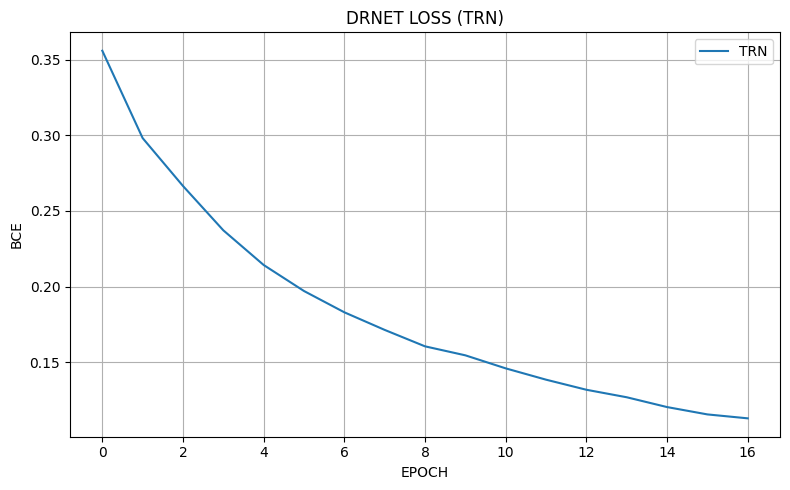

In [16]:
kwargs = dict(
    record=records["trn"],
    label="TRN",
    criterion="BCE",
    title="DRNET LOSS (TRN)",
)

utils.visualizer.main(**kwargs)

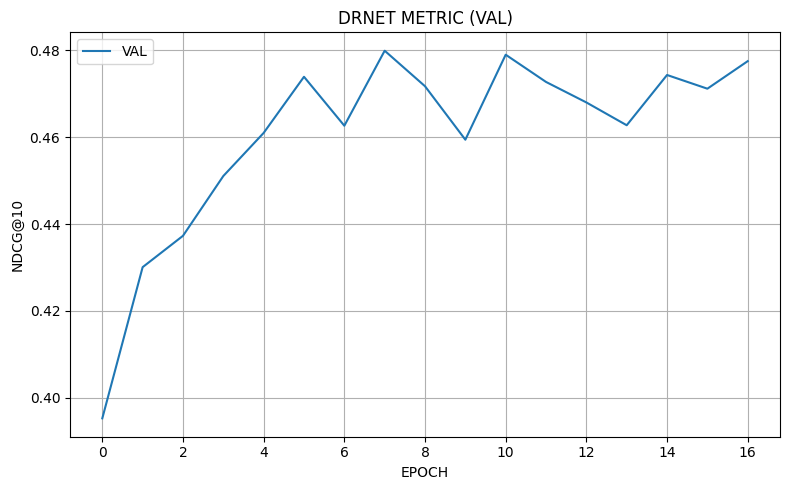

In [17]:
kwargs = dict(
    record=records["val"],
    label="VAL",
    criterion="NDCG@10",
    title="DRNET METRIC (VAL)",
)

utils.visualizer.main(**kwargs)

# Test

In [18]:
kwargs = dict(
    model=model,
    cfg=cfg.evaluator,
)

evaluator = evaluator.builder.evaluator_builder(**kwargs)

In [19]:
result, metrics_sheet = evaluator(dataloaders["tst"])

TST: 100%|██████████| 3195/3195 [00:40<00:00, 78.56it/s]


In [20]:
metrics_sheet

,k,hit_ratio,precision,recall,map,ndcg
0,5,0.842105,0.366447,0.319321,0.229377,0.449480
1,10,0.939145,0.286513,0.457899,0.282150,0.472113
2,15,0.963816,0.234759,0.526829,0.302405,0.485601
3,20,0.980263,0.202220,0.577080,0.313693,0.497471
4,25,0.985197,0.179211,0.607140,0.320822,0.505651
5,50,0.993421,0.117566,0.712624,0.338800,0.536936


# Save

In [21]:
PATH = f'./checkpoints/{cfg.dataset}/{cfg.model_cls}_{cfg.strategy}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)